# Project 2: LeNet-5 Build From Scratch
# Handwritten Digit Recognition with MNIST

**Task:** Build a LeNet-5 model from scratch and apply it on the MNIST dataset.

**Target:** Accuracy ≥ 95%

**Author:** Trầm Tính Ân - 24520074

---


# 1. Load MNIST Dataset


In [1]:
import torchvision
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

transform = transforms.ToTensor()

# MNIST - Train data
trainset = torchvision.datasets.MNIST(root='./data', train=True,
                                      download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32,
                                          shuffle=True, num_workers=2)

# MNIST - Test data
testset = torchvision.datasets.MNIST(root='./data', train=False,
                                     download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=32,
                                         shuffle=False, num_workers=2)

classes = ('0', '1', '2', '3', '4', '5', '6', '7', '8', '9')

print(f"Training set: {len(trainset)} images")
print(f"Test set: {len(testset)} images")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


100.0%
100.0%
100.0%
100.0%

Training set: 60000 images
Test set: 10000 images
Using device: cpu


## 1.1 Data Exploration


In [2]:
batch = next(iter(trainloader))
print(f"Batch images shape: {batch[0].shape}")  # [32, 1, 28, 28]
print(f"Batch labels shape: {batch[1].shape}")
print(f"Image size: {batch[0].shape[2]}x{batch[0].shape[3]}")
print(f"Channels: {batch[0].shape[1]} (grayscale)")


Batch images shape: torch.Size([32, 1, 28, 28])
Batch labels shape: torch.Size([32])
Image size: 28x28
Channels: 1 (grayscale)


## 1.2 Visualize Samples


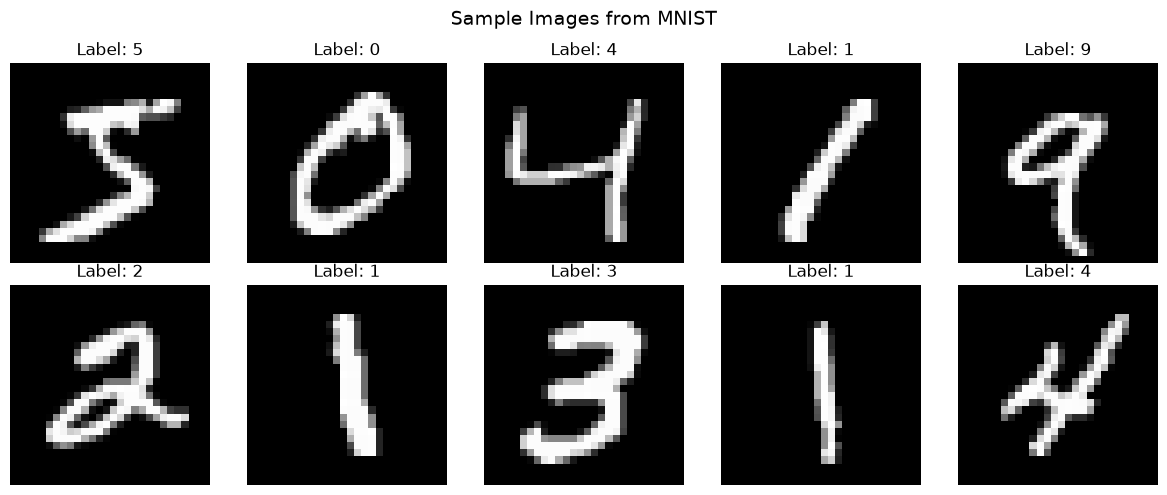

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Sample Images from MNIST", fontsize=14)

for i in range(10):
    row, col = i // 5, i % 5
    img, label = trainset[i]
    axes[row, col].imshow(img.squeeze(), cmap='gray')
    axes[row, col].set_title(f"Label: {label}")
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()


---
# 2. Build LeNet-5 Model

## Architecture

```
Input (1x28x28)
  -> C1: Conv2d(1->6, 5x5, padding=2) + ReLU     -> 6x28x28
  -> S2: AvgPool2d(2x2)                            -> 6x14x14
  -> C3: Conv2d(6->16, 5x5)           + ReLU       -> 16x10x10
  -> S4: AvgPool2d(2x2)                            -> 16x5x5
  -> C5: Conv2d(16->120, 5x5)         + ReLU       -> 120x1x1
  -> Flatten                                        -> 120
  -> F6: Linear(120->84)              + ReLU        -> 84
  -> Output: Linear(84->10)                         -> 10
```


In [4]:
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()

        # C1: Convolutional layer 1 (1->6, 5x5, padding=2 to keep 28x28)
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=2)
        self.relu1 = nn.ReLU()
        # S2: Average Pooling (28x28 -> 14x14)
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)

        # C3: Convolutional layer 2 (6->16, 5x5, no padding: 14x14 -> 10x10)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=0)
        self.relu2 = nn.ReLU()
        # S4: Average Pooling (10x10 -> 5x5)
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)

        # C5: Convolutional layer 3 (16->120, 5x5: 5x5 -> 1x1)
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5, stride=1, padding=0)
        self.relu3 = nn.ReLU()

        self.flatten = nn.Flatten()

        # F6: Fully connected (120 -> 84)
        self.fc1 = nn.Linear(120, 84)
        self.relu4 = nn.ReLU()

        # Output: Fully connected (84 -> 10)
        self.fc2 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.relu3(self.conv3(x))
        x = self.flatten(x)
        x = self.relu4(self.fc1(x))
        x = self.fc2(x)
        return x


In [5]:
model = LeNet5().to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

x = torch.randn(32, 1, 28, 28).to(device)
y = model(x)
print(f"\nInput shape: {x.shape}")
print(f"Output shape: {y.shape}")


LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu1): ReLU()
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (relu2): ReLU()
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv3): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
  (relu3): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=120, out_features=84, bias=True)
  (relu4): ReLU()
  (fc2): Linear(in_features=84, out_features=10, bias=True)
)

Total parameters: 61,706

Input shape: torch.Size([32, 1, 28, 28])
Output shape: torch.Size([32, 10])


---
# 3. Training

## 3.1 Loss Function & Optimizer


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer}")


Loss function: CrossEntropyLoss()
Optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


## 3.2 Training & Evaluation Function


In [7]:
def train_and_evaluate(model, trainloader, testloader, criterion, optimizer, num_epochs=2):
    """Train and evaluate model across epochs."""
    train_losses = []
    test_accuracies = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for i, data in enumerate(trainloader):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            if i % 500 == 499:
                print(f"  Epoch {epoch+1}, batch {i+1}, loss: {running_loss/500:.4f}")
                running_loss = 0.0

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for data in testloader:
                images, labels = data
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        test_accuracies.append(accuracy)
        print(f"Epoch {epoch+1}/{num_epochs}, Test Accuracy: {accuracy:.2f}%")

    return test_accuracies


## 3.3 Start Training


In [8]:
NUM_EPOCHS = 30

print(f"Training LeNet-5 on {device} for {NUM_EPOCHS} epochs...")
print("=" * 60)

accuracies = train_and_evaluate(model, trainloader, testloader,
                                criterion, optimizer, num_epochs=NUM_EPOCHS)

print("=" * 60)
print(f"Final Test Accuracy: {accuracies[-1]:.2f}%")
print(f"Best Test Accuracy: {max(accuracies):.2f}%")


Training LeNet-5 on cpu for 30 epochs...
  Epoch 1, batch 500, loss: 2.2998
  Epoch 1, batch 1000, loss: 2.2921
  Epoch 1, batch 1500, loss: 2.2122
Epoch 1/30, Test Accuracy: 83.30%
  Epoch 2, batch 500, loss: 0.5136
  Epoch 2, batch 1000, loss: 0.3954
  Epoch 2, batch 1500, loss: 0.3478
Epoch 2/30, Test Accuracy: 92.20%
  Epoch 3, batch 500, loss: 0.2678
  Epoch 3, batch 1000, loss: 0.2291
  Epoch 3, batch 1500, loss: 0.2108
Epoch 3/30, Test Accuracy: 94.42%
  Epoch 4, batch 500, loss: 0.1694
  Epoch 4, batch 1000, loss: 0.1654
  Epoch 4, batch 1500, loss: 0.1574
Epoch 4/30, Test Accuracy: 95.95%
  Epoch 5, batch 500, loss: 0.1349
  Epoch 5, batch 1000, loss: 0.1329
  Epoch 5, batch 1500, loss: 0.1250
Epoch 5/30, Test Accuracy: 96.82%
  Epoch 6, batch 500, loss: 0.1169
  Epoch 6, batch 1000, loss: 0.1140
  Epoch 6, batch 1500, loss: 0.1044
Epoch 6/30, Test Accuracy: 97.29%
  Epoch 7, batch 500, loss: 0.0930
  Epoch 7, batch 1000, loss: 0.0906
  Epoch 7, batch 1500, loss: 0.0923
Epoch 

---
# 4. Evaluation

## 4.1 Accuracy Curve


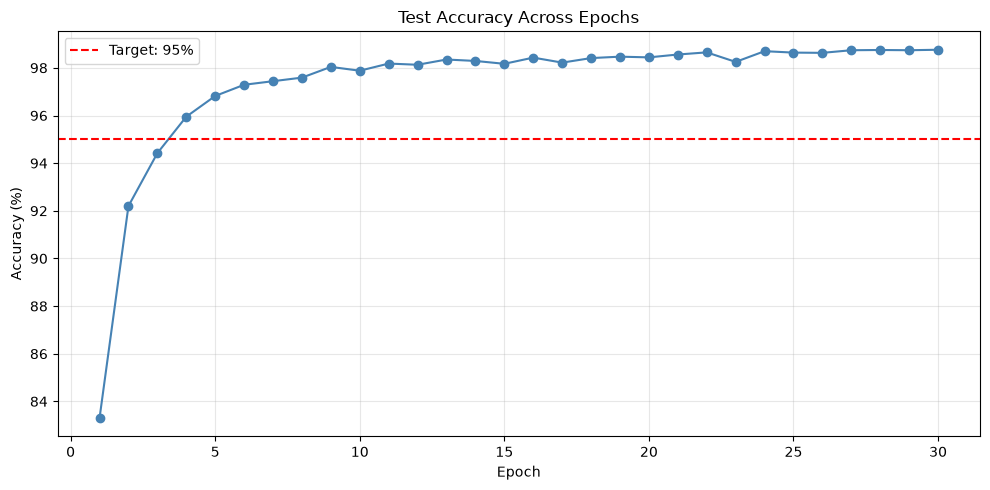

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(accuracies)+1), accuracies, marker='o', color='steelblue')
plt.axhline(y=95, color='red', linestyle='--', label='Target: 95%')
plt.title('Test Accuracy Across Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4.2 Predictions on Test Samples


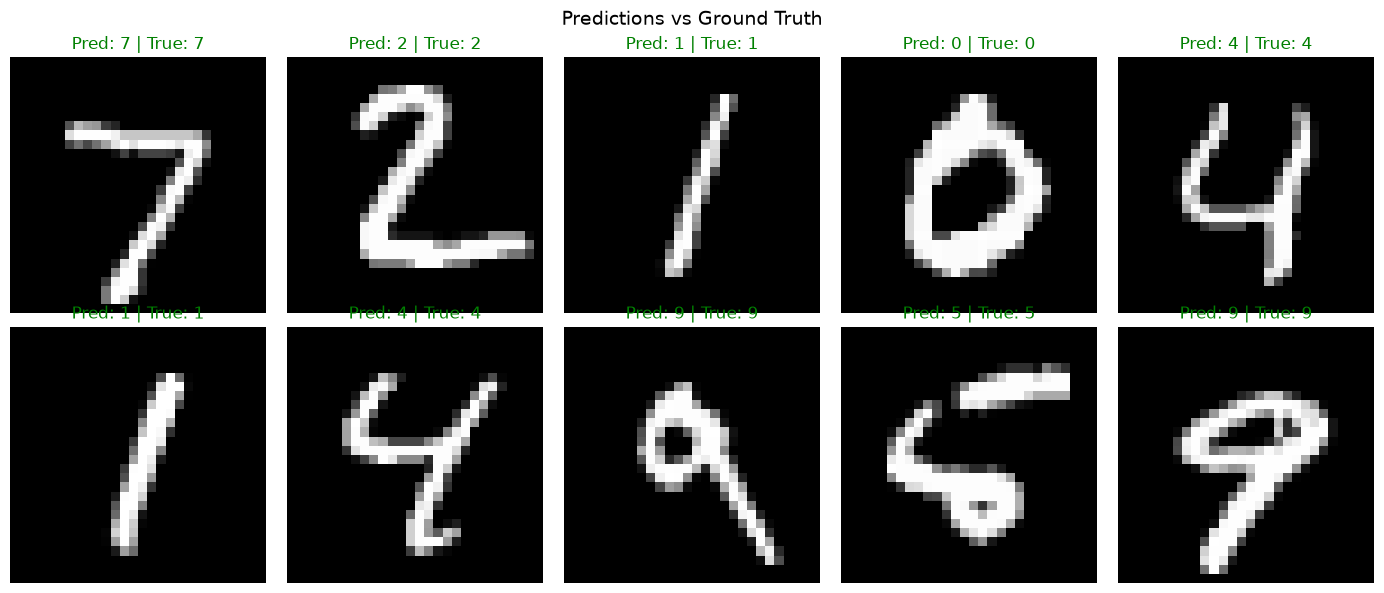

In [10]:
test_images, test_labels = next(iter(testloader))
test_images, test_labels = test_images.to(device), test_labels.to(device)

model.eval()
with torch.no_grad():
    outputs = model(test_images)
    _, predicted = torch.max(outputs, 1)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Predictions vs Ground Truth", fontsize=14)

for i in range(10):
    row, col = i // 5, i % 5
    img = test_images[i].cpu().squeeze()
    pred = predicted[i].item()
    true = test_labels[i].item()
    axes[row, col].imshow(img, cmap='gray')
    color = 'green' if pred == true else 'red'
    axes[row, col].set_title(f"Pred: {pred} | True: {true}", color=color)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()


## 4.3 Confusion Matrix


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.98      0.99       982
           5       0.99      0.98      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      0.99      0.98      1028
           8       0.99      0.98      0.99       974
           9       0.97      0.99      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



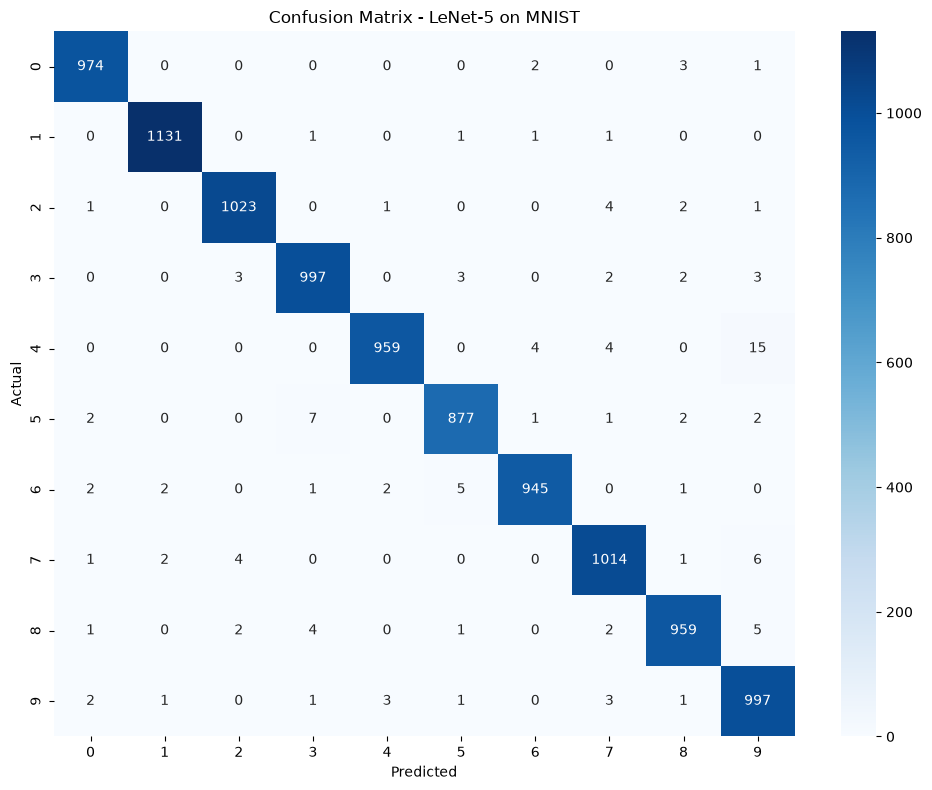

In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=[str(i) for i in range(10)]))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix - LeNet-5 on MNIST')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


---
# 5. Bonus: Improved LeNet-5

Improvements:
- Add **BatchNorm** after each Conv layer
- Replace **AvgPool** with **MaxPool**
- Add **Dropout** to prevent overfitting
- Use **Adam** optimizer instead of SGD


In [12]:
class ImprovedLeNet5(nn.Module):
    """Improved LeNet-5 with BatchNorm, MaxPool, and Dropout."""
    def __init__(self):
        super(ImprovedLeNet5, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, padding=2),
            nn.BatchNorm2d(6),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(6, 16, kernel_size=5),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 120, kernel_size=5),
            nn.BatchNorm2d(120),
            nn.ReLU(),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(84, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

improved_model = ImprovedLeNet5().to(device)
improved_optimizer = torch.optim.Adam(improved_model.parameters(), lr=0.001)

print(f"Improved LeNet-5 - Parameters: {sum(p.numel() for p in improved_model.parameters()):,}")
print("\nTraining Improved LeNet-5...")
improved_accuracies = train_and_evaluate(improved_model, trainloader, testloader,
                                         criterion, improved_optimizer, num_epochs=15)
print(f"\nFinal Accuracy: {improved_accuracies[-1]:.2f}%")
print(f"Best Accuracy: {max(improved_accuracies):.2f}%")


Improved LeNet-5 - Parameters: 61,990

Training Improved LeNet-5...
  Epoch 1, batch 500, loss: 0.3217
  Epoch 1, batch 1000, loss: 0.1140
  Epoch 1, batch 1500, loss: 0.0948
Epoch 1/15, Test Accuracy: 98.59%
  Epoch 2, batch 500, loss: 0.0637
  Epoch 2, batch 1000, loss: 0.0646
  Epoch 2, batch 1500, loss: 0.0589
Epoch 2/15, Test Accuracy: 98.93%
  Epoch 3, batch 500, loss: 0.0525
  Epoch 3, batch 1000, loss: 0.0465
  Epoch 3, batch 1500, loss: 0.0443
Epoch 3/15, Test Accuracy: 98.99%
  Epoch 4, batch 500, loss: 0.0396
  Epoch 4, batch 1000, loss: 0.0404
  Epoch 4, batch 1500, loss: 0.0410
Epoch 4/15, Test Accuracy: 98.82%
  Epoch 5, batch 500, loss: 0.0338
  Epoch 5, batch 1000, loss: 0.0343
  Epoch 5, batch 1500, loss: 0.0372
Epoch 5/15, Test Accuracy: 99.01%
  Epoch 6, batch 500, loss: 0.0327
  Epoch 6, batch 1000, loss: 0.0297
  Epoch 6, batch 1500, loss: 0.0347
Epoch 6/15, Test Accuracy: 99.14%
  Epoch 7, batch 500, loss: 0.0245
  Epoch 7, batch 1000, loss: 0.0338
  Epoch 7, batc

## 5.1 Original vs Improved Comparison


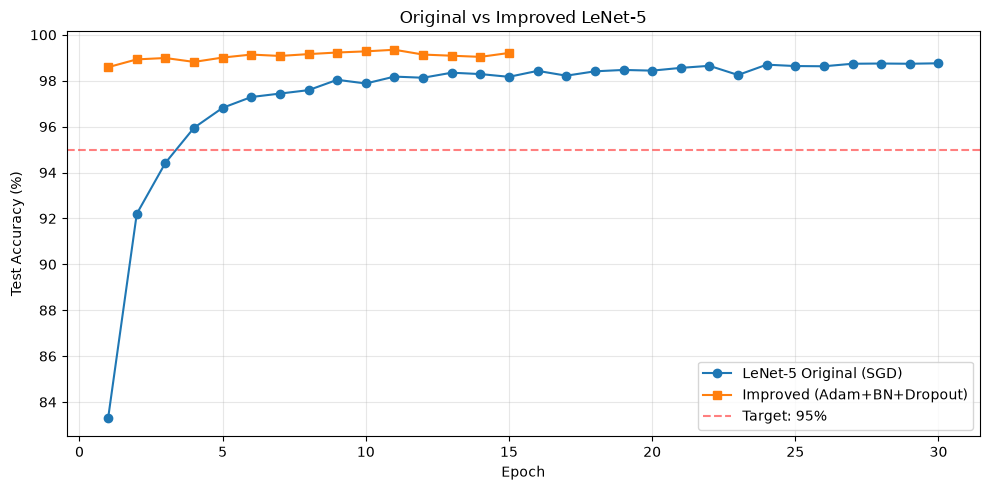

Original LeNet-5 Best: 98.76%
Improved LeNet-5 Best: 99.35%


In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(accuracies)+1), accuracies, marker='o', label='LeNet-5 Original (SGD)')
ax.plot(range(1, len(improved_accuracies)+1), improved_accuracies, marker='s', label='Improved (Adam+BN+Dropout)')
ax.axhline(y=95, color='red', linestyle='--', alpha=0.5, label='Target: 95%')
ax.set_title('Original vs Improved LeNet-5')
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Original LeNet-5 Best: {max(accuracies):.2f}%")
print(f"Improved LeNet-5 Best: {max(improved_accuracies):.2f}%")


---
# 6. Conclusion

- The original LeNet-5 achieves accuracy above 95% after about 5-10 epochs, demonstrating the effectiveness of CNNs for digit recognition.
- The improved version (with BatchNorm, MaxPool, Dropout, Adam) converges faster and can achieve even higher accuracy (>99%).
- LeNet-5, while simple, laid the foundation for modern CNN architectures like VGG, ResNet, etc.
